In [15]:
import pandas as pd
driver_species_20 = pd.read_csv('driver_species_20.csv')

In [88]:
driver_species_20['mean_relative_abundance'].max()

0.0002562215816321403

In [89]:
driver_species_20

,SAFE total score,number of enriched nodes,number of enriched samples,SAFE enriched score,enriched abundance ratio,enriched SAFE score ratio,mean_relative_abundance
name,,,,,,,
Candidatus Nanosynbacter lyticus,120.633165,181,26,115.781320,-0.582348,0.959780,4.970216e-05
Pseudomonas sp. GXZC,121.207558,170,24,114.193200,-0.217363,0.942129,1.664318e-06
Moraxella ovis,121.480528,159,23,114.168522,-0.730767,0.939809,2.236892e-04
Empedobacter stercoris,116.209928,155,21,111.149735,-0.243321,0.956456,2.170645e-05
Roseomonas mucosa,128.950480,158,22,110.686949,-0.588229,0.858368,2.573761e-05
Neisseria polysaccharea,114.654549,155,23,110.082637,-0.249447,0.960124,5.697313e-06
Stenotrophomonas sp. LM091,114.023056,156,24,109.714886,-0.199885,0.962217,2.040665e-06
Acholeplasma laidlawii,118.338607,172,28,109.467908,-0.281951,0.925040,2.253236e-06
Bradyrhizobium sp. ORS 278,113.027584,165,26,109.353666,-0.209037,0.967495,1.037221e-06


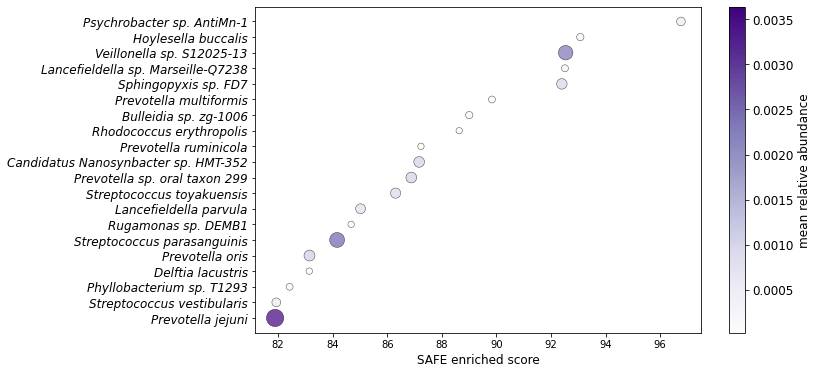

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

df_small = driver_species_20

plt.figure(figsize=(10, 6))

norm = mcolors.Normalize(vmin=driver_species_20['mean_relative_abundance'].min(), 
                         vmax=driver_species_20['mean_relative_abundance'].max())

scatter = sns.scatterplot(
    data=df_small,
    y=df_small.index,  # Microbes on y-axis
    x="SAFE enriched score",  # Score on x-axis
    size="mean_relative_abundance",  # Dot size based on mean abundance
    sizes=(40, 300),  # Adjust dot size range
    alpha=0.7,
    hue="mean_relative_abundance",  # Color the dots by abundance (optional)
    palette="Purples",  # Optional: change palette
    edgecolor="black",  # Circle borders are black
    linewidth=0.5,  # Set the thickness of the border
    legend=None,  
)

sm = plt.cm.ScalarMappable(cmap="Purples", norm=norm)
sm.set_array([])  
cbar = plt.colorbar(sm)
cbar.set_label("mean relative abundance", size=12)
cbar.ax.tick_params(labelsize=12)


plt.xticks()  
plt.xlabel("SAFE enriched score", size=12)
plt.ylabel("")
plt.gca().tick_params(axis='y', labelsize=12)  
plt.gca().yaxis.set_tick_params(labelrotation=0)
for label in plt.gca().get_yticklabels():
    label.set_fontstyle('italic')
plt.savefig('Driver_species_MT_LC_0405_new_clr.pdf', bbox_inches='tight')

In [155]:
edges_df_with_relative_abundance = pd.read_csv('edges_df_with_RL_LC_MT_HostT.csv', sep = '\t')

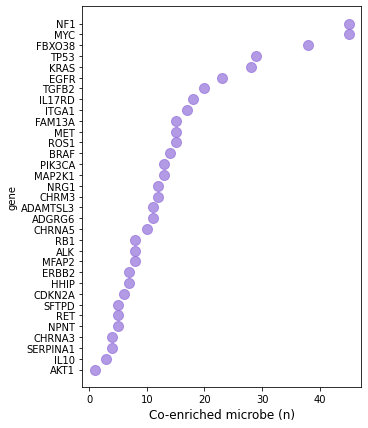

In [157]:
df = edges_df_with_relative_abundance
value_counts = df.iloc[:, 1].value_counts()

sorted_counts = value_counts.sort_values(ascending=True)
plt.figure(figsize=(5, 7))
plt.scatter(sorted_counts.values, sorted_counts.index, color="mediumpurple", s=100, alpha=0.7)
plt.xlabel("Co-enriched microbe (n)", size=12)
plt.ylabel("gene")
plt.title("")
plt.xticks()
plt.grid(axis="y", linestyle="", alpha=0.6)
plt.savefig('MT_coenriched_microbe_n_forgenes.pdf',bbox_inches='tight')